# Explorary Data Analysis Report 

## 1. Note

The detailed analysis is in `EDA.ipynb`. Helper functions are in `EDA.py`. Gold and US-Dollar-Index data are in folder `data\yfinance`, along with download script `yf_download.py`. Libraries as `yfinance, ipykernel, statsmodels` are added to `requirements.txt`.

## 2. Key findings

- Price signal is an autoregressive time series. The first degree difference of it is **stationary**. 
- **Price is the leading signal**. Other On-Chain variables in many time follow the change of price.
- The one-day differentiation of On-Chain data **eliminate potential co-integrations**.
- We found that on-chain variables interacted with bitcoin price are:
   - ```'AdrActCnt', 'CapMVRVCur', 'FeeTotNtv', 'HashRate', 'TxTfrCnt', 'gold', 'dollar'```
- We found 8 co-integrations between 12 variables.Among them:
 	- ```'BlkCnt', 'FeeTotNtv', 'CapMVRVCur'``` are with bigger coefficients.
- Significant **Correction Variables** of first cointegrations in On-Chain dataset:
    ```text
    ================================================================================
                        Variable         Alpha      Direction  P_Value Significance
    ================================================================================
    volume_reported_spot_usd_1d     1.026043e+02   ↑ upwards    0.000000       ***
                        HashRate    5.971085e-01   ↑ upwards    0.000000       ***
                        TxTfrCnt    3.569417e-03   ↑ upwards    0.000000       ***
                        AdrBalCnt  -7.410968e-04   ↓ downwards  0.000000       ***
                        BlkCnt      1.462194e-07   ↑ upwards    0.000004       ***
                    CapMVRVCur      7.834212e-10   ↑ upwards    0.047107       **
    ================================================================================
    ``` 
    Next we will utilize them trying to find reversion equations.
- There exists strong **reversion force** when **price deviates from MAs**. And there exists reversion force pushes **short term MA to longer MA**. We may exploit this structure for our allocation of weights.
- After rolling the time series and normalize ups and downs within window size, as example model did, we found that **polymarket volume and on-chain MVRV ratio may Granger Caused bitcoin price change**.
- We tried **3 versions** of polymarket data analysis by change the **data coverage** (btc only markets or all crypto markets), and **weighted the market volume by odds**.We will choose btc only markets data with odds weighted volume to design a reversion equation.And compare the results with Trilemma's benchmark.
    - Settings:
    ```text
        ==========================================================
        Method.             Diff. Variables
        ==========================================================
        1              BTC only markets, odds weighted volume
        2              All Crypto markets, odds weighted volume
        3              BTC only markets, original volume
        ==========================================================
        other variables: PriceUSD_coinmetrics, CapMVRVCur from Coin Metrics dataset
    ```
    - Significant variables found by VAR model
        - Method 1:
            ```text
                ====================================================
                   variable                coef                pvalue
                 ====================================================
                   L1.MVRV_pct             0.117672            0.020**
                   L1.price_pct            0.721150            0.000***
                   L2.price_pct            0.115791            0.024**
            ```
        - Method 2 and method 3 report similar coefficients while method 3 give a weak support(pvalue=0.066) for L2.price_pct.
- We are **lack of trading data** for technical analysis. The data download from yahoo finance started from 2014-09-17. If we have extra times, we may try working on yahoo finance data with methods other than reversion equations.

## 3. On-Chain Data Analysis


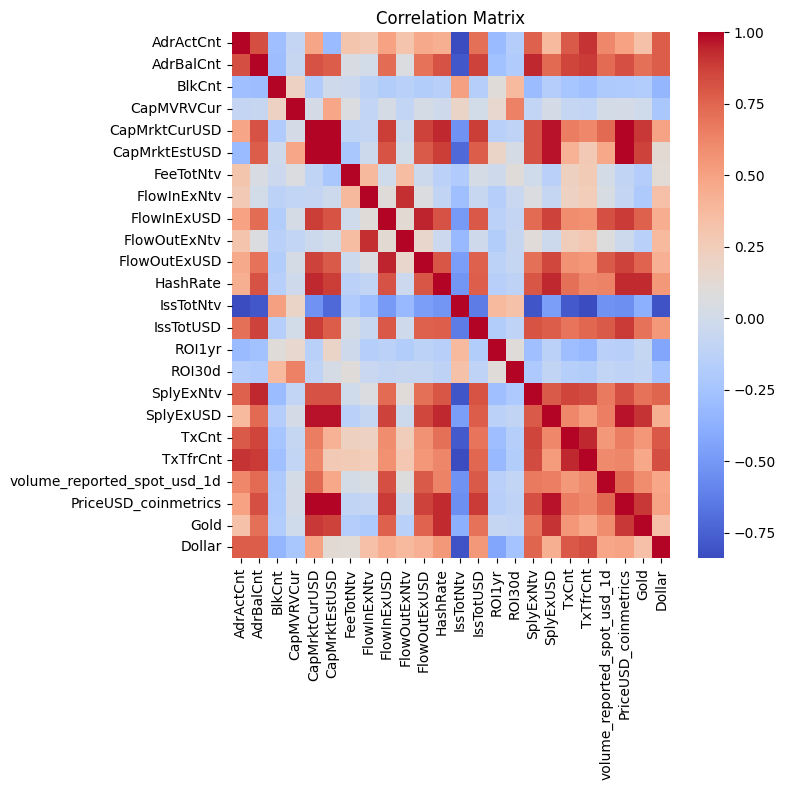

In [1]:
# prepare data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

notebook_dir = os.getcwd()

project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
sys.path.insert(0, project_root)

from template.prelude_template import load_polymarket_data, load_data
from EDA import *
btc = load_data()

# get gold price and dollar index data
gold = pd.read_csv(f'{project_root}/data/yfinance/GC_F.csv')
dollar = pd.read_csv(f'{project_root}/data/yfinance/DX-Y.NYB.csv')

gold["Date"] = pd.to_datetime(gold["Date"])
dollar["Date"] = pd.to_datetime(dollar["Date"])

gold.set_index("Date", inplace=True)
dollar.set_index("Date", inplace=True)

# merge dataframe
btc_merge = pd.merge(left=btc, right=gold["Close"], how='left', left_index=True, right_index=True)
btc_merge.rename(columns={"Close":"Gold"},inplace=True)
btc_merge = pd.merge(left=btc_merge, right=dollar["Close"], how='left', left_index=True, right_index=True)
btc_merge.rename(columns={"Close":"Dollar"}, inplace=True)
btc_merge[["Gold", "Dollar"]] = btc_merge[["Gold", "Dollar"]].ffill()

# drop unuseful columns, and plot correlation heatmap
btc_merge.drop(columns=["AssetCompletionTime", 
                "AssetEODCompletionTime", 
                "PriceBTC", 
                "SplyCur",
                "PriceUSD",
                "SplyExpFut10yr",
                "ReferenceRate", 
                "ReferenceRateETH",
                "ReferenceRateEUR",
                "ReferenceRateUSD"], 
                inplace = True)
btc_merge = btc_merge.loc["2010-07-18":]
corr_matrix, corr_heatmap = compute_plot_coor(btc_merge)

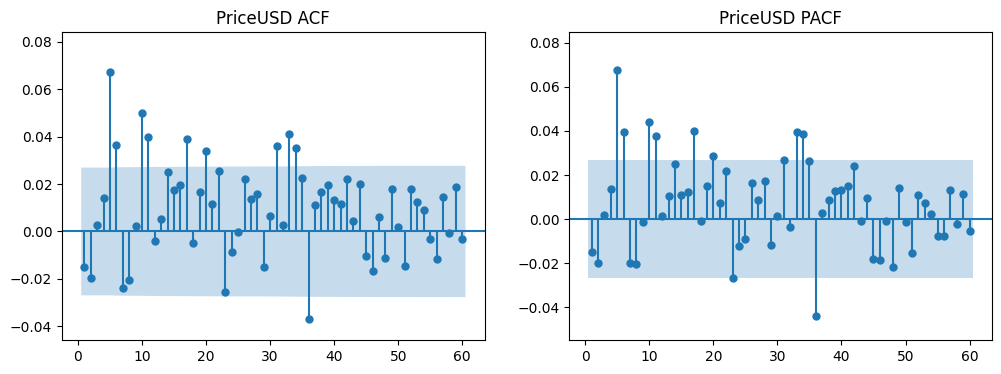

In [2]:
# Get 1 day difference data, and de-mean the data
# Market cap is identical to price, drop them
# Combine FlowInExUSD and FlowOutExUSD

NetFlowInExUSD = pd.DataFrame(btc_merge['FlowInExUSD'] - btc_merge["FlowOutExUSD"], columns=["NetFlowInExUSD"])
NetFlowInExNtv = pd.DataFrame(btc_merge["FlowInExNtv"] - btc_merge["FlowOutExNtv"], columns=["NetFlowInExNtv"])

btc_merge  = pd.merge(left=btc_merge, right=NetFlowInExNtv, how='left', left_index=True, right_index=True)
btc_merge = pd.merge(left=btc_merge, right=NetFlowInExUSD, how='left', left_index=True, right_index=True)

btc_merge.drop(columns=["CapMrktEstUSD", "CapMrktCurUSD", "FlowInExUSD", "FlowOutExUSD", "FlowInExNtv", "FlowOutExNtv"], inplace=True)
btc_1d_diff_demean = differatiate_data(btc_merge, period=1)

# acf/pacf plot of 1 day differentiated data
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1,2,figsize=(12,4))
plot_acf(btc_1d_diff_demean["PriceUSD_coinmetrics"], lags=60, ax=ax[0], title="PriceUSD ACF", zero=False, auto_ylims=True)
plot_pacf(btc_1d_diff_demean["PriceUSD_coinmetrics"], lags=60, ax=ax[1], title="PriceUSD PACF", zero=False, auto_ylims=True)
plt.show()

In [3]:
# Johansen cointegration test only support 12 variables
data = btc_merge[["AdrBalCnt", "BlkCnt",  "FeeTotNtv", "CapMVRVCur", "HashRate", "IssTotNtv", 
                  "TxTfrCnt", "volume_reported_spot_usd_1d", "PriceUSD_coinmetrics", "Gold", "Dollar"]]

rank, result = johansen_coint_test(data.dropna())
print("cointegration rank:",rank)
vecm_result = vecm(data.dropna(), r=rank)

# Strong Cointegration confirmed

cointegration rank: 8
Optimal lag length for VAR: 2
VECM will use 1 lags of differences


- Long term dynamics (top 6 cointegrations):
    - (1) 0 = PriceUSD_coinmetrics - 1505.68*Dollar - 1.1067*Gold; 
    - (2) 0 = PriceUSD_coinmetrics + 13345.47*BlkCnt + 10168.41*Dollar + 126.34*Gold; 
    - (3) 0 = PriceUSD_coinmetrics + 668.63*FeeTotNtv - 400.17*Dollar + 17.60*Gold; 
    - (4) 0 = PriceUSD_coinmetrics + 24379.59*CapMVRVCur + 1107.47*Dollar + 22.65*Gold; 
    - (5) 0 = PriceUSD_coinmetrics - 2664.40*Dollar - 99.53*Gold; 
    - (6) 0 = PriceUSD_coinmetrics + 2215.48*Dollar + 10.18*IssTotNtv + 0.7747*Gold;
- After plotting interested variables with bit price, we may choose ```'AdrBalCnt', 'FeeTotNtv', 'HashRate', 'TxTfrCnt', 'volume_reported_spot_usd_1d'``` to test mean-reversion force.
- The slope of ```'HashRate', 'volume_reported_spot_usd_1d'``` >> slope of ```'PriceUSD_coinmetrics'``` >> slope of ```'AdrBalCnt','TxTfrCnt'```. This may suggests some **structural emotion hype**. And there may exists reversion force.

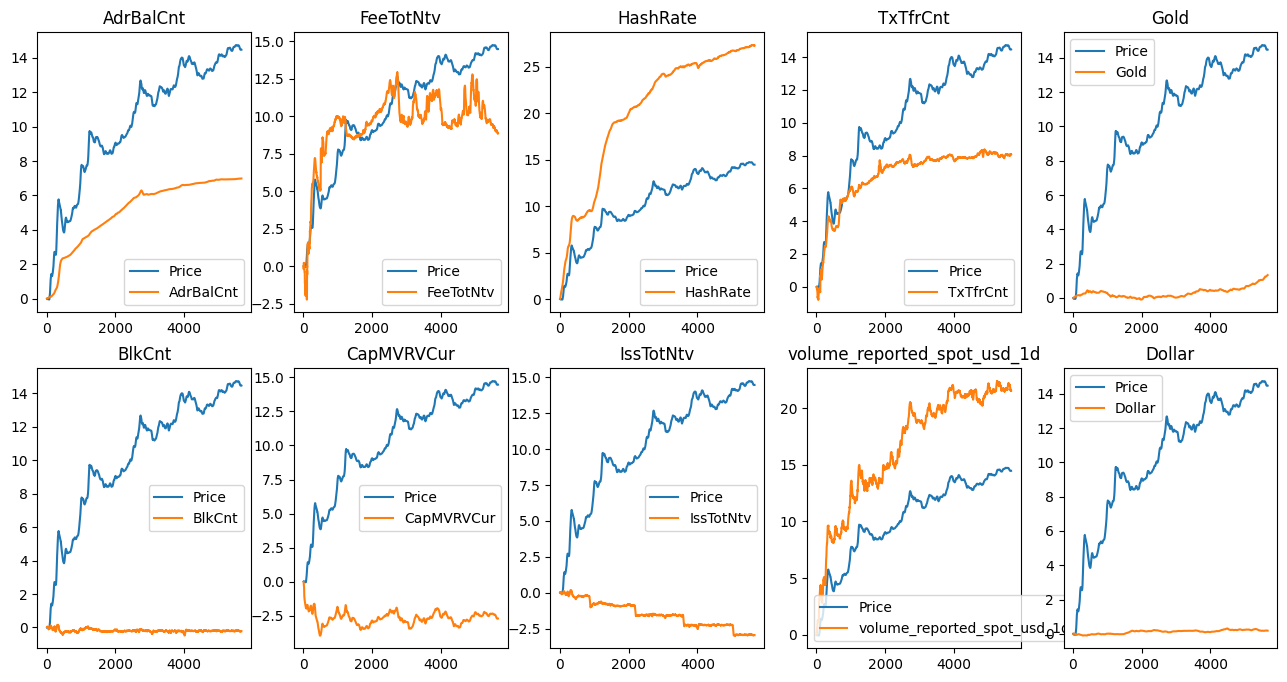

In [4]:
fig,ax = plt.subplots(2,5,figsize=(16,8))
coordinates = [[i,j] for j in range(5) for i in range(2)]

d = data['PriceUSD_coinmetrics'].rolling(window=30, min_periods=15).mean().pct_change().cumsum()
k = 0
for col in data.columns:
    if col != 'PriceUSD_coinmetrics':
        e = data[col].rolling(window=30, min_periods=15).mean().pct_change().cumsum()
        i, j = coordinates[k]
        ax[i][j].plot(np.arange(len(data)), d, label='Price')
        ax[i][j].plot(np.arange(len(data)), e, label=col)
        ax[i][j].set_title(col)
        ax[i][j].legend()
        k += 1

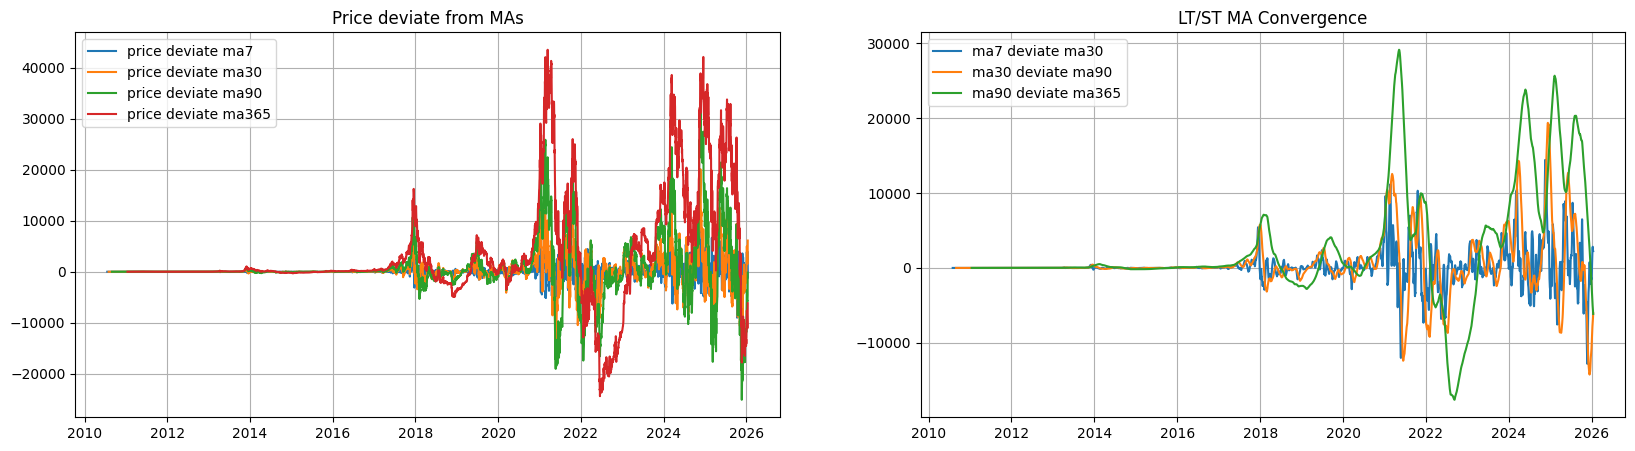

In [5]:
# Price Converges to Moving Average

price = btc_merge['PriceUSD_coinmetrics']
ma7 = price.rolling(window=7, min_periods=3).mean()
ma30 = price.rolling(window=30, min_periods=15).mean()
ma90 = price.rolling(window=90, min_periods=45).mean()
ma365 = price.rolling(window=365, min_periods=182).mean()

fig, ax = plt.subplots(1,2, figsize=(20,5))
ax[0].plot(price - ma7, label='price deviate ma7')
ax[0].plot(price - ma30, label='price deviate ma30')
ax[0].plot(price - ma90, label='price deviate ma90')
ax[0].plot(price - ma365, label='price deviate ma365')
ax[0].set_title('Price deviate from MAs')
ax[0].grid()
ax[0].legend()

ax[1].plot(ma7 - ma30, label='ma7 deviate ma30')
ax[1].plot(ma30 - ma90, label='ma30 deviate ma90')
ax[1].plot(ma90 - ma365, label='ma90 deviate ma365')
ax[1].set_title('LT/ST MA Convergence')
ax[1].grid()
ax[1].legend()

plt.show()

## 2. Poly-Market Data Analysis

In [6]:
# Method 1, stationary check and vector autoregressive test

poly_market = POLY()
features = poly_market.prepare_features()

# Augment Dicky-Fuller Test check stationary
adf = AD_Fuller_Test(features[['market_count_pct', 'volume_pct', 'price_pct', 'MVRV_pct']])
print("Feature Name \t\t Statistics \t\t pvalue \n==============================================================")
for k,v in adf.items():
    if k != 'critic value':
        print(f"{k.ljust(15)} \t\t {str(round(v['AD_Fuller_Statistics'], 4)).ljust(10)} \t\t {round(v['pvalue'], 4)}")

# vector auto-regressive model fitting
var_results = vec_ar_test(features[['market_count_pct', 'volume_pct', 'MVRV_pct', 'price_pct']], y = "price_pct")

/home/jason/bitcoin-analytics-capstone-template/eda/EDA.py:507: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .apply(lambda x : (x[-1] > x[:-1]).sum() / max(len(x) - 1, 1) if len(x) > 1 else 0.5)


Feature Name 		 Statistics 		 pvalue 
market_count_pct 		 -3.6061    		 0.0056
volume_pct      		 -4.4365    		 0.0003
price_pct       		 -9.1227    		 0.0
MVRV_pct        		 -9.5118    		 0.0
The optimal BIC lags number is 2


- 
  - VAR Test Results
    ```text
    Significant variables of VAR model for equation price_pct from method 2 and 3

    method 1:
    ====================================================
      variable                coef                pvalue
    ====================================================
      L1.MVRV_pct             0.117672            0.020**
      L1.price_pct            0.721150            0.000***
      L2.price_pct            0.115791            0.024**

    method 2:
    ====================================================
      variable                coef                pvalue
    ====================================================
      L1.MVRV_pct             0.113909            0.020**
      L1.price_pct            0.724770            0.000***
      L2.price_pct            0.115888            0.024**

    method 3:
    ====================================================
      variable                coef                pvalue
    ====================================================
      L1.MVRV_pct             0.118789            0.021**
      L1.price_pct            0.728760            0.000***
      L2.price_pct            0.115691            0.066*

    Note: All models report similar coefficients whereas method 3 give a weak support for L2.price_pct
```

In [7]:
# run granger causality test, try lags=3
gc_btc_1d_diff_demean = granger_test(features[['market_count_pct', 'volume_pct', 'MVRV_pct', 'price_pct']], y = "price_pct", lags=3)

Testing Granger Causality from market_count_pct to price_pct

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1795  , p=0.6718  , df_denom=1927, df_num=1
ssr based chi2 test:   chi2=0.1798  , p=0.6715  , df=1
likelihood ratio test: chi2=0.1798  , p=0.6715  , df=1
parameter F test:         F=0.1795  , p=0.6718  , df_denom=1927, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.1725  , p=0.8416  , df_denom=1924, df_num=2
ssr based chi2 test:   chi2=0.3459  , p=0.8412  , df=2
likelihood ratio test: chi2=0.3459  , p=0.8412  , df=2
parameter F test:         F=0.1725  , p=0.8416  , df_denom=1924, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.1752  , p=0.9132  , df_denom=1921, df_num=3
ssr based chi2 test:   chi2=0.5274  , p=0.9128  , df=3
likelihood ratio test: chi2=0.5273  , p=0.9128  , df=3
parameter F test:         F=0.1752  , p=0.9132  , df_denom=1921, df_num=3
Testing Granger Causality f

-
    - Granger Causality Test Resulst
        ```text
            Granger Causality from variables to price_pct:
            method 1:
             ==============================================
                   variable        lag         pvalue
             ==============================================
                   volume_pct      L1          0.0381**
                   volume_pct      L2          0.0896*
                   MVRV_pct        L2          0.0539*
                   MVRV_pct        L3          0.0027***

             method 2:
             Granger Causality from variables to price_pct:
             ==============================================
                   variable        lag         pvalue
             ==============================================
                   MVRV_pct        L2          0.0539*
                   MVRV_pct        L3          0.0027***

             method 3:
             Granger Causality from variables to price_pct:
             ==============================================
                   variable        lag         pvalue
             ==============================================
                   volume_pct      L1          0.0002***
                   volume_pct      L2          0.0011***
                   volume_pct      L3          0.0047***
                   MVRV_pct        L2          0.0539*
                   MVRV_pct        L3          0.0027***
        ```

In [8]:
data = features[["daily_market_count", "daily_volume",  "PriceUSD_coinmetrics", 'CapMVRVCur']]

rank, result = johansen_coint_test(data.dropna())
print("cointegration rank:",rank)
vecm_result = vecm(data.dropna(), r=rank)

# find 3 cointegrations in a 4 dimensions dataset

cointegration rank: 3
Optimal lag length for VAR: 2
VECM will use 1 lags of differences


## End